In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Extract Here done ✅")

Extract Here done ✅


In [ ]:
import pandas as pd

df = pd.read_csv("train/_annotations.csv")

labels_per_image = df.groupby("filename")["class"].nunique()
labels_per_image.value_counts()

,count
class,
2,501
1,410
3,143
4,21


In [ ]:
import os
import pandas as pd
from PIL import Image

In [ ]:
# paths
BASE_DIR = "train"
CSV_PATH = os.path.join(BASE_DIR, "_annotations.csv")
IMAGES_DIR = BASE_DIR

# output directory for cropped images
OUTPUT_DIR = "train_cropped"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
df = pd.read_csv(CSV_PATH)

df.head(), df.shape

(                                           filename  width  height     class  \
 0  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
 1  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256  Fillings   
 2  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
 3  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
 4  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
 
    xmin  ymin  xmax  ymax  
 0   175   116   206   153  
 1   170   109   189   133  
 2   221   124   257   178  
 3   302   126   329   175  
 4   335   114   360   154  ,
 (8030, 8))

In [ ]:
df.columns

Index(['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax'], dtype='object')

In [ ]:
classes = df["class"].unique().tolist()
classes

['Implant', 'Fillings', 'Impacted Tooth', 'Cavity']

In [ ]:
for cls in classes:
    class_dir = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(class_dir, exist_ok=True)

In [ ]:
os.listdir(OUTPUT_DIR)

['Cavity', 'Implant', 'Impacted Tooth', 'Fillings']

In [ ]:
row = df.iloc[0]
row

,0
filename,0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg
width,512
height,256
class,Implant
xmin,175
ymin,116
xmax,206
ymax,153


In [ ]:
img_path = os.path.join(IMAGES_DIR, row["filename"])
img = Image.open(img_path).convert("RGB")

crop = img.crop((
    row["xmin"],
    row["ymin"],
    row["xmax"],
    row["ymax"]
))

crop

In [ ]:
save_name = f"test_{row.name}.jpg"
save_path = os.path.join(OUTPUT_DIR, row["class"], save_name)

crop.save(save_path)

save_path

'train_cropped/Implant/test_0.jpg'

In [ ]:
os.listdir(os.path.join(OUTPUT_DIR, row["class"]))

['test_0.jpg']

In [ ]:
from tqdm import tqdm

skipped = 0
saved = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(IMAGES_DIR, row["filename"])

    if not os.path.exists(img_path):
        skipped += 1
        continue

    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    xmin = max(0, int(row["xmin"]))
    ymin = max(0, int(row["ymin"]))
    xmax = min(w, int(row["xmax"]))
    ymax = min(h, int(row["ymax"]))

    # validate box
    if xmax <= xmin or ymax <= ymin:
        skipped += 1
        continue

    crop = img.crop((xmin, ymin, xmax, ymax))

    if crop.size[0] == 0 or crop.size[1] == 0:
        skipped += 1
        continue

    save_name = f"{os.path.splitext(row['filename'])[0]}_{idx}.jpg"
    save_path = os.path.join(OUTPUT_DIR, row["class"], save_name)

    crop.save(save_path)
    saved += 1

print("Saved:", saved)
print("Skipped:", skipped)

100%|██████████| 8030/8030 [00:10<00:00, 761.44it/s]

Saved: 8027
Skipped: 3


In [ ]:
for cls in classes:
    print(cls, len(os.listdir(os.path.join(OUTPUT_DIR, cls))))

Implant 1785
Fillings 5239
Impacted Tooth 428
Cavity 576


In [ ]:
import shutil
from sklearn.model_selection import train_test_split

BASE_DIR = "data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

for cls in classes:
    os.makedirs(os.path.join(TRAIN_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cls), exist_ok=True)

for cls in classes:
    imgs = os.listdir(os.path.join(OUTPUT_DIR, cls))

    train_imgs, val_imgs = train_test_split(
        imgs,
        test_size=0.2,
        random_state=42
    )

    for img in train_imgs:
        shutil.copy(
            os.path.join(OUTPUT_DIR, cls, img),
            os.path.join(TRAIN_DIR, cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(OUTPUT_DIR, cls, img),
            os.path.join(VAL_DIR, cls, img)
        )


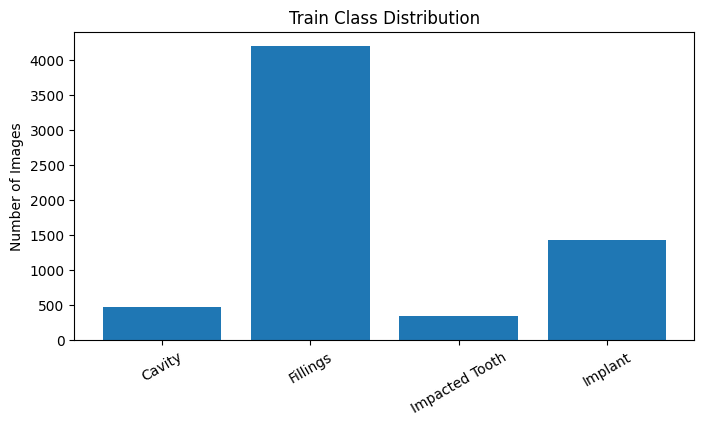

In [ ]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Calculate train_counts
train_data = []
for cls in classes:
    class_path = os.path.join(TRAIN_DIR, cls)
    num_images = len(os.listdir(class_path))
    train_data.append({"class": cls, "count": num_images})

train_counts = pd.DataFrame(train_data).set_index("class")

plt.figure(figsize=(8,4))
plt.bar(train_counts.index, train_counts["count"])
plt.title("Train Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

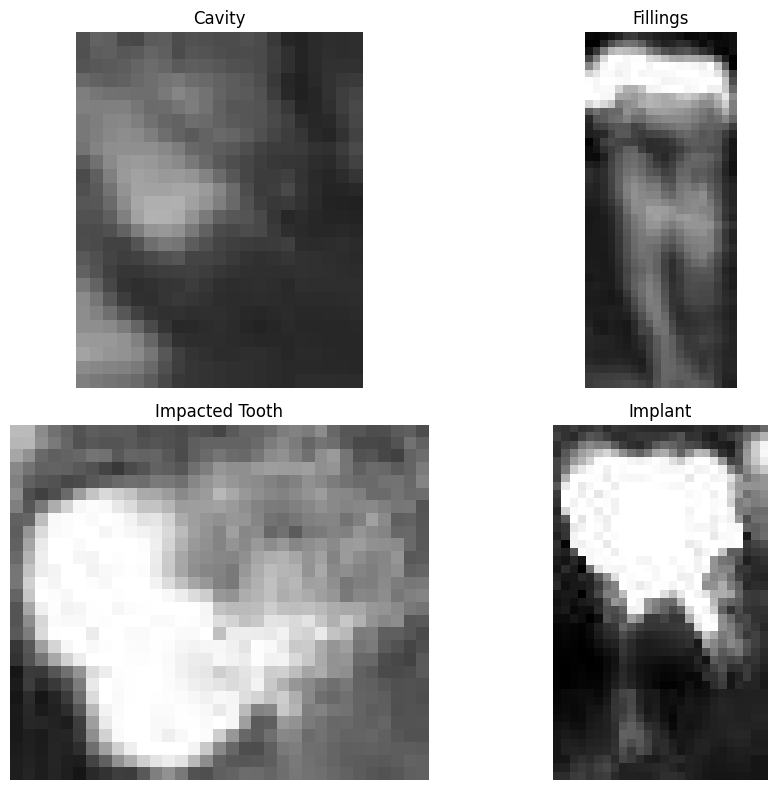

In [ ]:
import random
from PIL import Image

plt.figure(figsize=(10,8))

classes = train_counts.index.tolist()

for i, cls in enumerate(classes):
    cls_dir = os.path.join("data/train", cls)
    img_name = random.choice(os.listdir(cls_dir))
    img_path = os.path.join(cls_dir, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 2, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

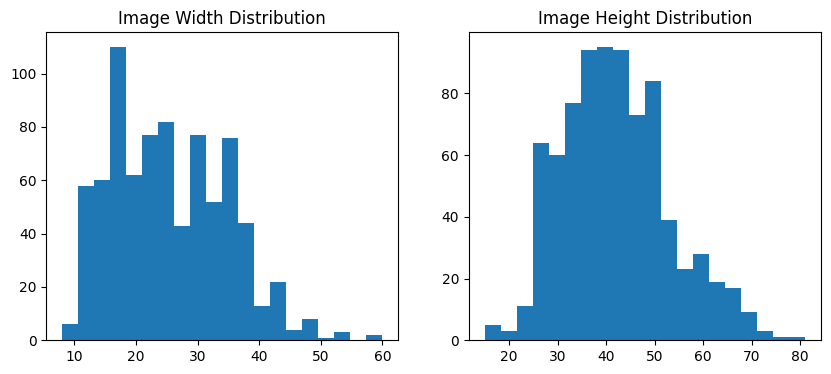

In [ ]:
import numpy as np

widths, heights = [], []

for cls in classes:
    cls_dir = os.path.join("data/train", cls)
    for img_name in os.listdir(cls_dir)[:200]:  # sample for speed
        img = Image.open(os.path.join(cls_dir, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")

plt.show()

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
from PIL import Image
import os

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def clahe_transform(image):
    def _clahe(img):
        img = img.numpy()

        if img.dtype != np.uint8:
            img = img.astype(np.uint8)

        if img.ndim == 3 and img.shape[-1] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        return clahe.apply(img)

    image = tf.py_function(_clahe, [image], tf.uint8)
    image.set_shape([None, None])
    return image

    image = tf.py_function(
        _clahe,
        [image],
        Tout=tf.uint8
    )

    # shape بعد CLAHE
    image.set_shape([None, None])
    return image

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomSharpness(0.5),
])

def train_preprocess(image, label):

    image = clahe_transform(image)
    image = tf.expand_dims(image, -1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = data_augmentation(image, training=True)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    image = tf.cast(image, tf.float32) / 255.0
    image = (image - 0.5) / 0.5

    return image, label


def val_preprocess(image, label):

    image = clahe_transform(image)
    image = tf.expand_dims(image, -1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32) / 255.0
    image = (image - 0.5) / 0.5

    return image, label
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    label_mode="int",
    shuffle=True,
    batch_size=None   # ❗ مهم
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/val",
    label_mode="int",
    shuffle=False,
    batch_size=None   # ❗ مهم
)

Found 6421 files belonging to 4 classes.
Found 1607 files belonging to 4 classes.


In [ ]:
import tensorflow as tf

train_ds = (
    train_ds
    .map(train_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(val_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
import tensorflow as tf
import numpy as np
from collections import Counter

# get labels from train dataset
train_labels = []

for _, labels in train_ds.unbatch():
    train_labels.append(int(labels.numpy()))

# count samples per class
class_counts = Counter(train_labels)

# sort by class index
class_counts = dict(sorted(class_counts.items()))

print("Class counts:", class_counts)

# compute weights: total_samples / (num_classes * class_count)
num_classes = len(class_counts)
total_samples = sum(class_counts.values())

class_weights = [
    total_samples / (num_classes * class_counts[i])
    for i in range(num_classes)
]

class_weights = tf.constant(class_weights, dtype=tf.float32)

print("Class weights:", class_weights)

Class counts: {0: 460, 1: 4191, 2: 342, 3: 1428}
Class weights: tf.Tensor([3.4896739  0.38302314 4.6937137  1.1241246 ], shape=(4,), dtype=float32)


In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    layers.Conv2D(32, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(128, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(256, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),   # زي AdaptiveAvgPool2d(1)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4)   # logits (no softmax)
])

# loss
criterion = losses.SparseCategoricalCrossentropy(from_logits=True)

# optimizer
optimizer = optimizers.Adam(
    learning_rate=1e-4,
    weight_decay=1e-4
)

# compile
model.compile(
    optimizer=optimizer,
    loss=criterion,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,172 (1.61 MB)

 Trainable params: 422,212 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [28]:
import tensorflow as tf

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [29]:
import tensorflow as tf
from tqdm import tqdm
import numpy as np

EPOCHS = 40

# ===== HISTORY =====
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

# ===== METRICS =====
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric   = tf.keras.metrics.SparseCategoricalAccuracy()

# ===== CLASS WEIGHTS =====
class_weight_tensor = tf.constant(
    [float(class_weights[i]) for i in range(len(class_weights))],
    dtype=tf.float32
)

# ===== EARLY STOPPING PARAMS =====
best_val_loss = float("inf")
early_stop_patience = 5
early_stop_counter = 0

# ===== LR SCHEDULER PARAMS (ReduceLROnPlateau) =====
lr_patience = 3
lr_counter = 0
lr_factor = 0.3
min_lr = 1e-6

# ===== TRAINING LOOP =====
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS} [TRAIN]")
    running_loss = 0.0
    train_acc_metric.reset_state()

    # ===== TRAIN =====
    for images, labels in tqdm(train_ds):
        with tf.GradientTape() as tape:
            outputs = model(images, training=True)
            loss = criterion(labels, outputs)

            # apply class weights
            weights = tf.gather(class_weight_tensor, labels)
            loss = tf.reduce_mean(loss * weights)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        running_loss += loss.numpy()
        train_acc_metric.update_state(labels, outputs)

    train_loss = running_loss / tf.data.experimental.cardinality(train_ds).numpy()
    train_acc  = train_acc_metric.result().numpy()

    # ===== VALIDATION =====
    print(f"Epoch {epoch+1}/{EPOCHS} [VAL]")
    val_loss = 0.0
    val_acc_metric.reset_state()

    for images, labels in tqdm(val_ds):
        outputs = model(images, training=False)
        loss = criterion(labels, outputs)

        weights = tf.gather(class_weight_tensor, labels)
        loss = tf.reduce_mean(loss * weights)

        val_loss += loss.numpy()
        val_acc_metric.update_state(labels, outputs)

    val_loss /= tf.data.experimental.cardinality(val_ds).numpy()
    val_acc = val_acc_metric.result().numpy()

    # ===== SAVE BEST MODEL =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        lr_counter = 0
        model.save_weights("best_model.weights.h5")
    else:
        early_stop_counter += 1
        lr_counter += 1

    # ===== REDUCE LR ON PLATEAU =====
    if lr_counter >= lr_patience:
        old_lr = optimizer.learning_rate.numpy()
        new_lr = max(old_lr * lr_factor, min_lr)
        optimizer.learning_rate.assign(new_lr)
        lr_counter = 0
        print(f"LR reduced: {old_lr:.2e} → {new_lr:.2e}")

    # ===== EARLY STOPPING =====
    if early_stop_counter >= early_stop_patience:
        print("Early stopping triggered")
        break

    # ===== HISTORY =====
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # ===== PRINT =====
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )


Epoch 1/40 [TRAIN]


100%|██████████| 201/201 [01:50<00:00,  1.82it/s]


Epoch 1/40 [VAL]


100%|██████████| 51/51 [00:04<00:00, 10.23it/s]


Epoch [1/40] | Train Loss: 0.7592 | Train Acc: 0.7405 | Val Loss: 1.4903 | Val Acc: 0.0722

Epoch 2/40 [TRAIN]


100%|██████████| 201/201 [01:40<00:00,  2.00it/s]


Epoch 2/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  8.63it/s]


Epoch [2/40] | Train Loss: 0.5464 | Train Acc: 0.8144 | Val Loss: 1.3717 | Val Acc: 0.1531

Epoch 3/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 3/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.43it/s]


Epoch [3/40] | Train Loss: 0.4700 | Train Acc: 0.8416 | Val Loss: 0.8317 | Val Acc: 0.5208

Epoch 4/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 4/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.57it/s]


Epoch [4/40] | Train Loss: 0.4398 | Train Acc: 0.8505 | Val Loss: 0.6651 | Val Acc: 0.8712

Epoch 5/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 5/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  4.98it/s]


Epoch [5/40] | Train Loss: 0.4022 | Train Acc: 0.8594 | Val Loss: 0.6142 | Val Acc: 0.8880

Epoch 6/40 [TRAIN]


100%|██████████| 201/201 [01:39<00:00,  2.02it/s]


Epoch 6/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.02it/s]


Epoch [6/40] | Train Loss: 0.3833 | Train Acc: 0.8715 | Val Loss: 0.5718 | Val Acc: 0.8892

Epoch 7/40 [TRAIN]


100%|██████████| 201/201 [01:39<00:00,  2.02it/s]


Epoch 7/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.96it/s]


Epoch [7/40] | Train Loss: 0.3666 | Train Acc: 0.8748 | Val Loss: 0.5917 | Val Acc: 0.8749

Epoch 8/40 [TRAIN]


100%|██████████| 201/201 [01:39<00:00,  2.03it/s]


Epoch 8/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.26it/s]


Epoch [8/40] | Train Loss: 0.3458 | Train Acc: 0.8819 | Val Loss: 0.6513 | Val Acc: 0.9017

Epoch 9/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 9/40 [VAL]


100%|██████████| 51/51 [00:06<00:00,  8.50it/s]


Epoch [9/40] | Train Loss: 0.3285 | Train Acc: 0.8902 | Val Loss: 0.5388 | Val Acc: 0.9141

Epoch 10/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 10/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.66it/s]


Epoch [10/40] | Train Loss: 0.3141 | Train Acc: 0.8935 | Val Loss: 0.4470 | Val Acc: 0.9235

Epoch 11/40 [TRAIN]


100%|██████████| 201/201 [01:39<00:00,  2.02it/s]


Epoch 11/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.25it/s]


Epoch [11/40] | Train Loss: 0.3138 | Train Acc: 0.8911 | Val Loss: 0.4502 | Val Acc: 0.9147

Epoch 12/40 [TRAIN]


100%|██████████| 201/201 [01:38<00:00,  2.03it/s]


Epoch 12/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  4.98it/s]


Epoch [12/40] | Train Loss: 0.3050 | Train Acc: 0.8957 | Val Loss: 0.5932 | Val Acc: 0.8731

Epoch 13/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 13/40 [VAL]


100%|██████████| 51/51 [00:06<00:00,  8.41it/s]


Epoch [13/40] | Train Loss: 0.2896 | Train Acc: 0.9006 | Val Loss: 0.4212 | Val Acc: 0.9203

Epoch 14/40 [TRAIN]


100%|██████████| 201/201 [01:38<00:00,  2.04it/s]


Epoch 14/40 [VAL]


100%|██████████| 51/51 [00:05<00:00, 10.03it/s]


Epoch [14/40] | Train Loss: 0.2869 | Train Acc: 0.9044 | Val Loss: 0.5088 | Val Acc: 0.8699

Epoch 15/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 15/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.20it/s]


Epoch [15/40] | Train Loss: 0.2879 | Train Acc: 0.9045 | Val Loss: 0.5148 | Val Acc: 0.9197

Epoch 16/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 16/40 [VAL]


100%|██████████| 51/51 [00:06<00:00,  8.39it/s]


Epoch [16/40] | Train Loss: 0.2698 | Train Acc: 0.9095 | Val Loss: 0.3478 | Val Acc: 0.9371

Epoch 17/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 17/40 [VAL]


100%|██████████| 51/51 [00:06<00:00,  8.49it/s]


Epoch [17/40] | Train Loss: 0.2609 | Train Acc: 0.9143 | Val Loss: 0.4218 | Val Acc: 0.9322

Epoch 18/40 [TRAIN]


100%|██████████| 201/201 [01:38<00:00,  2.03it/s]


Epoch 18/40 [VAL]


100%|██████████| 51/51 [00:05<00:00, 10.15it/s]


Epoch [18/40] | Train Loss: 0.2678 | Train Acc: 0.9066 | Val Loss: 0.4146 | Val Acc: 0.9154

Epoch 19/40 [TRAIN]


100%|██████████| 201/201 [01:38<00:00,  2.04it/s]


Epoch 19/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  8.76it/s]


LR reduced: 1.00e-04 → 3.00e-05
Epoch [19/40] | Train Loss: 0.2576 | Train Acc: 0.9105 | Val Loss: 0.3918 | Val Acc: 0.9291

Epoch 20/40 [TRAIN]


100%|██████████| 201/201 [01:38<00:00,  2.05it/s]


Epoch 20/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.96it/s]


Epoch [20/40] | Train Loss: 0.2349 | Train Acc: 0.9223 | Val Loss: 0.3651 | Val Acc: 0.9390

Epoch 21/40 [TRAIN]


100%|██████████| 201/201 [01:38<00:00,  2.04it/s]


Epoch 21/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.30it/s]


Epoch [21/40] | Train Loss: 0.2288 | Train Acc: 0.9240 | Val Loss: 0.3460 | Val Acc: 0.9415

Epoch 22/40 [TRAIN]


100%|██████████| 201/201 [01:39<00:00,  2.02it/s]


Epoch 22/40 [VAL]


100%|██████████| 51/51 [00:05<00:00, 10.13it/s]


Epoch [22/40] | Train Loss: 0.2259 | Train Acc: 0.9251 | Val Loss: 0.3771 | Val Acc: 0.9409

Epoch 23/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 23/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.59it/s]


Epoch [23/40] | Train Loss: 0.2195 | Train Acc: 0.9262 | Val Loss: 0.3962 | Val Acc: 0.9272

Epoch 24/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 24/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.09it/s]


LR reduced: 3.00e-05 → 9.00e-06
Epoch [24/40] | Train Loss: 0.2315 | Train Acc: 0.9256 | Val Loss: 0.3801 | Val Acc: 0.9384

Epoch 25/40 [TRAIN]


100%|██████████| 201/201 [01:38<00:00,  2.03it/s]


Epoch 25/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  8.74it/s]


Epoch [25/40] | Train Loss: 0.2080 | Train Acc: 0.9301 | Val Loss: 0.3405 | Val Acc: 0.9459

Epoch 26/40 [TRAIN]


100%|██████████| 201/201 [01:39<00:00,  2.03it/s]


Epoch 26/40 [VAL]


100%|██████████| 51/51 [00:05<00:00, 10.17it/s]


Epoch [26/40] | Train Loss: 0.2148 | Train Acc: 0.9319 | Val Loss: 0.3509 | Val Acc: 0.9477

Epoch 27/40 [TRAIN]


100%|██████████| 201/201 [01:39<00:00,  2.03it/s]


Epoch 27/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  8.65it/s]


Epoch [27/40] | Train Loss: 0.2129 | Train Acc: 0.9288 | Val Loss: 0.3236 | Val Acc: 0.9477

Epoch 28/40 [TRAIN]


100%|██████████| 201/201 [01:38<00:00,  2.03it/s]


Epoch 28/40 [VAL]


100%|██████████| 51/51 [00:04<00:00, 10.33it/s]


Epoch [28/40] | Train Loss: 0.2112 | Train Acc: 0.9310 | Val Loss: 0.3274 | Val Acc: 0.9496

Epoch 29/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 29/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.39it/s]


Epoch [29/40] | Train Loss: 0.2083 | Train Acc: 0.9343 | Val Loss: 0.3349 | Val Acc: 0.9496

Epoch 30/40 [TRAIN]


100%|██████████| 201/201 [01:38<00:00,  2.04it/s]


Epoch 30/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  8.79it/s]


LR reduced: 9.00e-06 → 2.70e-06
Epoch [30/40] | Train Loss: 0.2167 | Train Acc: 0.9313 | Val Loss: 0.3365 | Val Acc: 0.9496

Epoch 31/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 31/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.63it/s]


Epoch [31/40] | Train Loss: 0.2010 | Train Acc: 0.9333 | Val Loss: 0.3282 | Val Acc: 0.9508

Epoch 32/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 32/40 [VAL]


100%|██████████| 51/51 [00:05<00:00,  9.63it/s]

Early stopping triggered


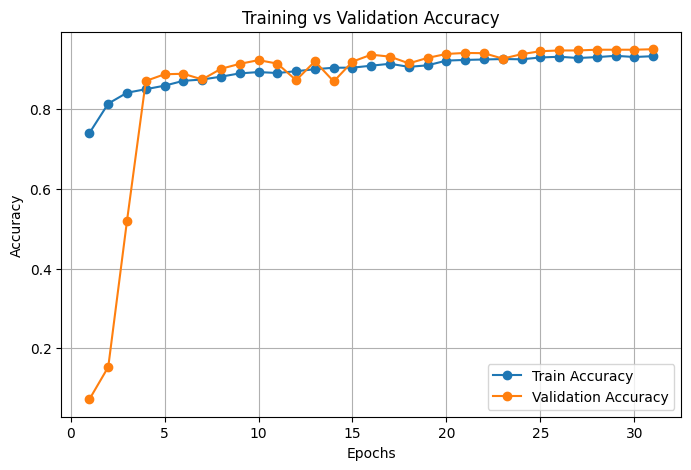

In [30]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy", marker="o")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

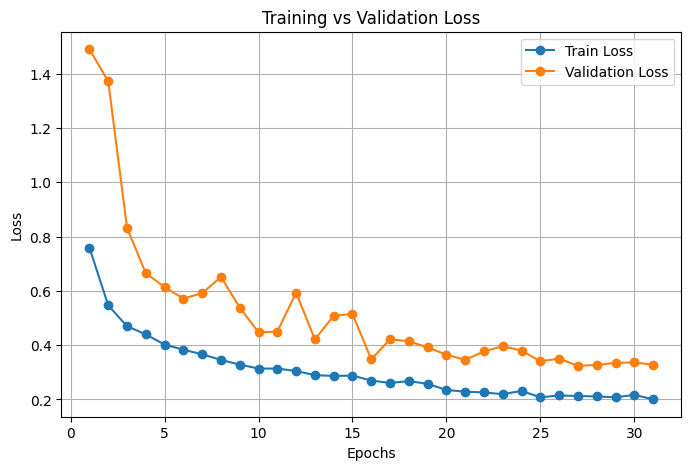

In [31]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs, history["val_loss"], label="Validation Loss", marker="o")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/val",
    label_mode="int",
    shuffle=False,
    batch_size=None
)

class_names = raw_val_ds.class_names

val_ds = (
    raw_val_ds
    .map(val_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

Found 1607 files belonging to 4 classes.


In [33]:
import tensorflow as tf
import numpy as np

y_pred = []
y_true = []

for images, labels in val_ds:
    outputs = model(images, training=False)
    preds = tf.argmax(outputs, axis=1)

    y_pred.extend(preds.numpy())
    y_true.extend(labels.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)



In [34]:
import numpy as np
import random

errors = np.where(y_pred != y_true)[0]
print("Total errors:", len(errors))

sample_errors = random.sample(list(errors), min(9, len(errors)))


Total errors: 79


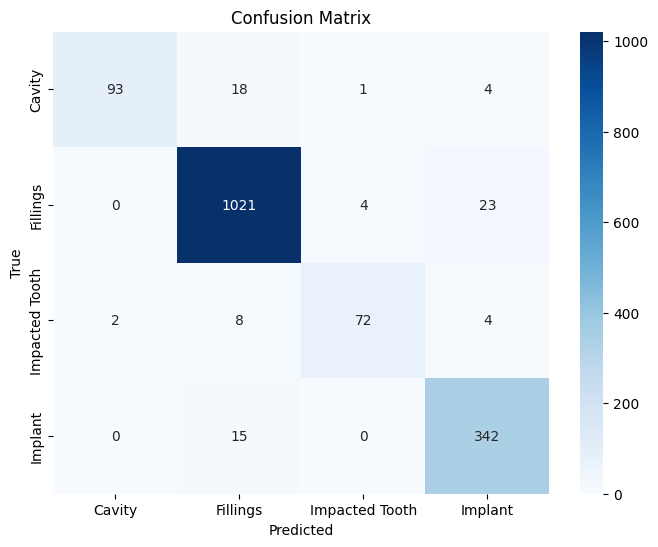

In [35]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                precision    recall  f1-score   support

        Cavity     0.9789    0.8017    0.8815       116
      Fillings     0.9614    0.9742    0.9678      1048
Impacted Tooth     0.9351    0.8372    0.8834        86
       Implant     0.9169    0.9580    0.9370       357

      accuracy                         0.9508      1607
     macro avg     0.9481    0.8928    0.9174      1607
  weighted avg     0.9514    0.9508    0.9502      1607



In [37]:
accuracy = (y_pred == y_true).mean() * 100
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 95.08%


In [38]:
import tensorflow as tf

model.save_weights("cnn_model.weights.h5")
print("Model saved successfully!")

Model saved successfully!


In [39]:
import json

history_clean = {
    k: [float(v) for v in values]
    for k, values in history.items()
}

with open("cnn_history.json", "w") as f:
    json.dump(history_clean, f, indent=4)

print("History saved successfully!")

History saved successfully!
